# 6.5 換 tokenizer 後如何比較模型？


同一原文，甲十token、平均代價0.6，乙五token、平均1.0。平均看似甲較低，總代價卻甲6、乙5。切法變了，「每token」就不是同一份文字，先回共同原文比較。

正確token的負對數機率加總叫 NLL。這裡用自然對數 ln，Python 的 `math.log` 也是這個底數；條件機率的乘積經負對數變成和，不需要字互相獨立。要改用以2為底的 bit 尺度，將總 NLL 除以 `ln(2)`：例如機率1/2的負自然對數為 `ln(2)≈0.6931`，除以同一數得到1 bit。再除以原文UTF-8 byte數，得到 BPB（bits per byte），也就是每個原文 byte 的平均 bit 代價。下面「貓🙂」共7 byte，手寫總NLL是5與4。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

In [2]:
import math

raw = "貓🙂"
bytes_count = len(raw.encode("utf-8"))
for name, total_nll in [("示例A", 5.0), ("示例B", 4.0)]:
    bpb = total_nll / (bytes_count * math.log(2))
    print(name, "原文bytes", bytes_count, "BPB", bpb)

示例A 原文bytes 7 BPB 1.030496457777831
示例B 原文bytes 7 BPB 0.8243971662222649


輸入同一原文貓與🙂，共三加四等於七bytes，長度差的來源見 [6.1](https://birdhackor.github.io/tiny-perceptron-vlm/6.1.html)。總NLL5與4是手工例子，尚非模型量測。輸出A約1.0305、B約0.8244，因為除數同為 `7×0.6931`，B較低表示這份原文總負對數代價較小。即使兩者token數不同，也回到了相同分母。

真正測量時，先用各自tokenizer編碼同一份驗證文件，再交給與它匹配的模型預測。有效目標位置是「有真實的下一文字單位，而且這次要替它計代價」的位置；只用來提供前文的內容，或為湊等長而額外填入的記號，不算本次的原文目標。把這些目標的負log機率加總，才是本次的總NLL。不能拿甲的ID丟進乙的模型，也不能只拿平均loss、沒有目標數量就推BPB。

圖裡兩條計算共用7byte分母。測長文時也須固定事件：窗口[A,B,C]計B、C，[B,C,D]只計D，別重複C；兩邊的已知開頭、可讀前文，以及結束記號 EOS（End of Sequence）的約定都要一致。本節實測把猜結束記號的代價算入總 NLL，但原文 byte 數只數原文字元，不包含這個額外記號；兩個模型都使用這份計分約定。


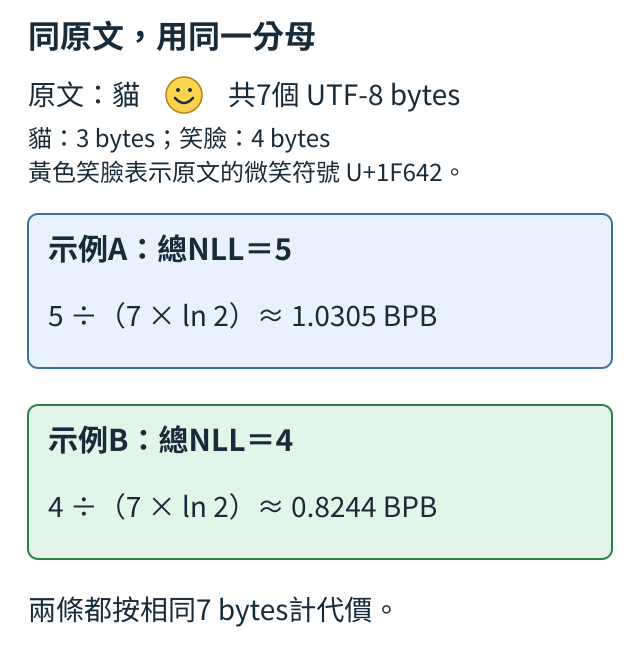

In [3]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-06-05-shared-denominator.svg")))

已有比較逐byte每token代價2.77947低於BPE的3.98741，BPB卻4.02906高於3.43401。固定原文曝光未固定參數、監督token與運算量，這示範單位的差別，不能外推工具優劣。

練習只把A與B的total_nll都乘2，先預測BPB都翻倍、排序不變，再執行核對。然後只把raw換成兩倍原文 `"貓🙂貓🙂"`，保留同一總NLL，數值會減半；這一步是在演示分母作用，真實模型換文本必須重測NLL，不能用舊數字當新結果。

<details>
<summary>補充：實作約定與原始紀錄</summary>

現在看真正的排名反轉。我們讓逐byte與BPE各自匹配的模型都更新400次，每次抽八篇；每一步用相同的原文片段，累計都看了664,759個原文byte。模型同樣寬度32、一層、最多384個位置，學習率0.003、種子42。在20篇最後檢查片段上，逐byte的每token代價2.77947，比BPE的3.98741低。可是前者計的是4,213個目標，後者只計2,503個；它們猜的不是同樣大的一口文字。


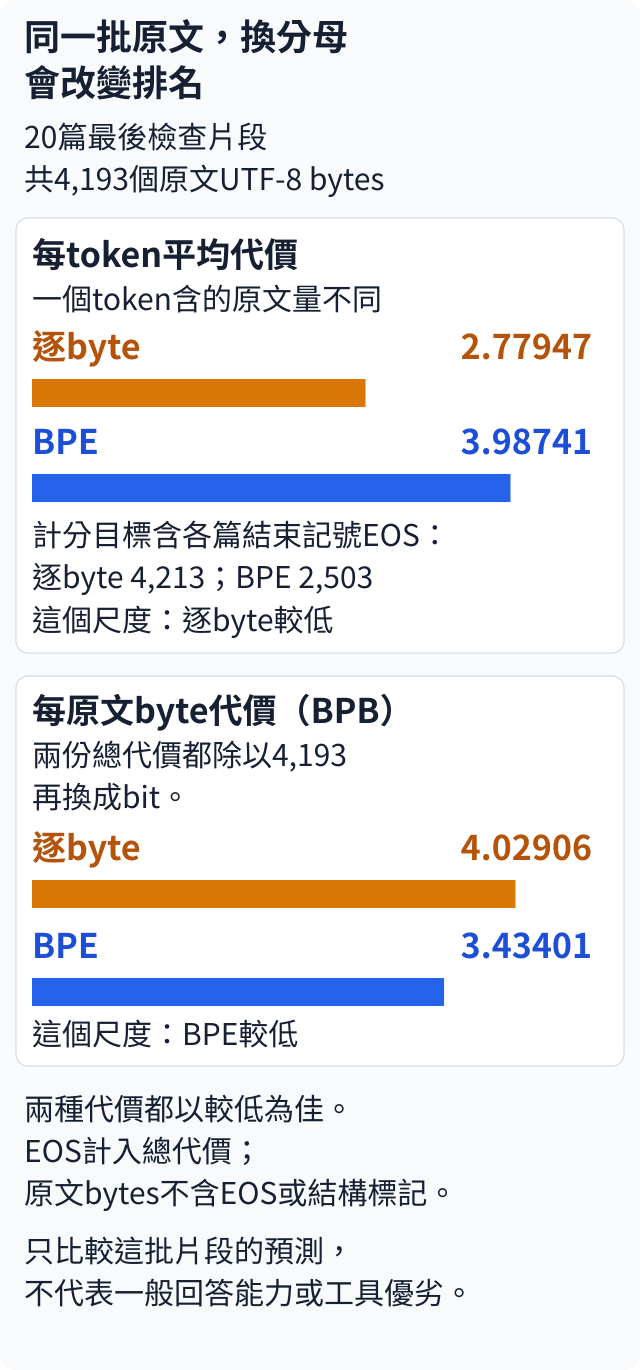

In [4]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/tokenizer_common_scale.svg")))

圖中下方的BPB區塊把兩份總代價都除以同一批原文4,193個byte，再換成bit；結束目標計入分子，結構標記不算原文bytes。逐byte的BPB是4.02906，BPE則是3.43401，這次共同尺度下反而BPE較低。驗證側也有同樣方向：逐byte的BPB由訓練前8.29037降至3.59830，BPE由5.04502降至3.06109。起始分數本來就不同，因為兩張字表定義的預測事件不同，不能把兩份隨機模型當作相同基線。

這次匹配的是原文曝光與更新次數，沒有匹配參數數量、監督token數或總運算量；[6.4](https://birdhackor.github.io/tiny-perceptron-vlm/6.4.html)已看到BPE模型多了參數。它回答的是這份小型混合資料、這個設定下怎麼讀比較，不能由此宣稱512是最佳詞表。生成也要另看：都准許寫32個新token時，BPE能寫的原文通常更長，不能把「寫得長」直接當成回答更好。[完整實測報告](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/tokenizer.json)保留各留出片段的生成，以及驗證與測試兩側彙總的每token代價和BPB。

短程式沿用本課工具與原計算語義。安裝、長訓練與重做操作見[訓練配方](https://birdhackor.github.io/tiny-perceptron-vlm/training.html)，不需要先完成長配方才能閱讀這個例子。

</details>
